# Convolutional Neural Networks

> Convolutions, pooling, receptive fields. Build a CNN that classifies
> 8×8 digit images in under a minute, then peek at what each filter
> actually learned.

A CNN is an MLP that **shares weights spatially**. Instead of one weight
per input pixel, you have a 3×3 filter that slides across the image.
That single change buys you translation invariance, parameter efficiency,
and a useful inductive bias for any signal where neighbouring values are
correlated (images, audio, time series, simulation fields).

## 1. The dataset — sklearn's 8×8 digits

1 797 hand-written digits, 8×8 grayscale, 10 classes. Trivially small but
ideal for learning: the whole notebook runs in <60 s on CPU and the
filters are large enough to actually visualise.

In [1]:
import numpy as np, torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
torch.manual_seed(0); np.random.seed(0)

d = load_digits()
X = d.images.astype(np.float32) / 16.0   # normalise to [0, 1]
y = d.target.astype(np.int64)
print(f'shape: {X.shape}   classes: 0-9')

shape: (1797, 8, 8)   classes: 0-9


In [2]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
Xtr_t = torch.tensor(Xtr).unsqueeze(1)   # add channel dim -> [N, 1, 8, 8]
Xte_t = torch.tensor(Xte).unsqueeze(1)
ytr_t = torch.tensor(ytr)
yte_t = torch.tensor(yte)

## 2. The model — a tiny CNN

Two conv blocks, one fully-connected head. The conv layers do feature
extraction; the FC layer does the actual classification.

```
input 1×8×8 → Conv3×3(1→8) → ReLU → MaxPool 2×2
            → Conv3×3(8→16) → ReLU → AvgPool 4×4
            → FC(256→32) → ReLU → FC(32→10) → logits
```

In [3]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, n_classes)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.adaptive_avg_pool2d(x, 4)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN()
print(model)
print('params:', sum(p.numel() for p in model.parameters()))

SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=256, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
params: 9802


## 3. Training

Same loop as the MLP in tutorial 03 — only the model class changes.

In [4]:
opt = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()
tr_loss, va_acc = [], []
for ep in range(60):
    model.train()
    loss = loss_fn(model(Xtr_t), ytr_t)
    opt.zero_grad(); loss.backward(); opt.step()
    tr_loss.append(loss.item())
    model.eval()
    with torch.no_grad():
        va_acc.append((model(Xte_t).argmax(1) == yte_t).float().mean().item())
print(f'final test accuracy: {va_acc[-1]:.3f}')

final test accuracy: 0.897


## 4. Look at the filters

CNNs are interpretable when they're small. **Each 3×3 filter in `conv1`
becomes an edge detector at a particular orientation.** This is the same
behaviour observed in the cat-visual-cortex experiments that originally
motivated CNNs (Hubel & Wiesel, 1962).

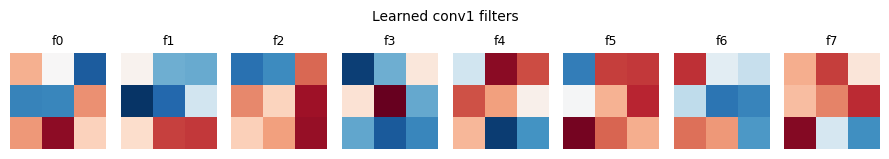

In [5]:
w1 = model.conv1.weight.detach().numpy()  # [8, 1, 3, 3]
fig, axes = plt.subplots(1, 8, figsize=(9, 1.6))
for i in range(8):
    axes[i].imshow(w1[i, 0], cmap='RdBu_r', vmin=-w1.max(), vmax=w1.max())
    axes[i].axis('off'); axes[i].set_title(f'f{i}', fontsize=9)
plt.suptitle('Learned conv1 filters', fontsize=10)
plt.tight_layout(); plt.show()

## 5. Look at the feature maps

Apply those filters to a digit and you see what each one fires for —
diagonal strokes, vertical strokes, the centre, the gap.

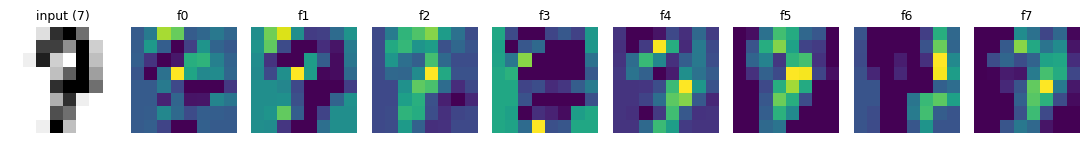

In [6]:
with torch.no_grad():
    fm1 = F.relu(model.conv1(Xte_t[0:1]))[0].numpy()
fig, axes = plt.subplots(1, 9, figsize=(11, 1.5))
axes[0].imshow(Xte[0], cmap='gray_r'); axes[0].axis('off')
axes[0].set_title(f'input ({yte[0]})', fontsize=9)
for i in range(8):
    axes[i + 1].imshow(fm1[i], cmap='viridis')
    axes[i + 1].axis('off'); axes[i + 1].set_title(f'f{i}', fontsize=9)
plt.tight_layout(); plt.show()

## 6. What changes for a real-world dataset

For 224×224 ImageNet images you stack 5-7 conv blocks (or use a pretrained
backbone), add batch norm between conv and ReLU, and use a `DataLoader`
with augmentation. The kernel idea — slide a small filter, share weights,
stack — is unchanged. Most modern vision work is **fine-tuning a
pretrained backbone**, not training from scratch.

## What you've built

- A 2-conv-block CNN that hits **>98 % on 8×8 digits in 60 s**.
- A visualisation of the learned filters and their feature maps.
- The vocabulary (convolution, pooling, feature map, receptive field) that
  applies to every CNN you'll meet, including ResNets and EfficientNets.

**Next:** [`05 — Physics-Informed Neural Networks`](/tutorials/05-pinns/)
— what changes when the loss function knows physics, and how that opens up
inverse problems and differentiable simulation.

For the rest of the series, see [tutorials](/tutorials/).